# Dataset Preprocessing following Weytjens and De Weerdt.

In [27]:
import time
import pandas as pd
import numpy as np
import random
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from pm4py.objects.log.importer.xes import importer as xes_importer
from pm4py.objects.log.exporter.xes import exporter as xes_exporter
from pm4py.objects.conversion.log import converter
import os

###############################################################################
# Utility: print basic dataset info
###############################################################################
def print_dataset_info(df, msg="Dataset info"):
    n_cases = df["case:concept:name"].nunique()
    n_rows = len(df)
    print(f"{msg}: {n_cases} cases, {n_rows} rows")

###############################################################################
# Steps 1 & 2: Filtering by start and end dates
###############################################################################
def start_from_date(dataset, start_date):
    print("\n=== Remove Cases that start before", start_date, "===")
    case_starts_df = dataset.groupby("case:concept:name")["time:timestamp"].min().reset_index()
    case_starts_df["date"] = case_starts_df["time:timestamp"].dt.to_period("M")
    cases_after = case_starts_df[case_starts_df["date"].astype(str) >= start_date]["case:concept:name"].values
    dataset = dataset[dataset["case:concept:name"].isin(cases_after)].reset_index(drop=True)
    print_dataset_info(dataset, f"After start_from_date >= {start_date}")
    return dataset

def end_before_date(dataset, end_date):
    print("\n=== Remove Cases that end after", end_date, "===")
    case_stops_df = dataset.groupby("case:concept:name")["time:timestamp"].max().reset_index()
    case_stops_df["date"] = case_stops_df["time:timestamp"].dt.to_period("M")
    cases_before = case_stops_df[case_stops_df["date"].astype(str) <= end_date]["case:concept:name"].values
    dataset = dataset[dataset["case:concept:name"].isin(cases_before)].reset_index(drop=True)
    print_dataset_info(dataset, f"After end_before_date <= {end_date}")
    return dataset

###############################################################################
# Step 3: Remove long cases and debias dataset endpoint
###############################################################################
def limited_duration(dataset, max_duration):
    print("\n=== Remove Long Cases (<= {} days) ===".format(max_duration))
    agg_dict = {"time:timestamp": ["min", "max"]}
    duration_df = dataset.groupby("case:concept:name").agg(agg_dict).reset_index()
    duration_df["duration"] = (
        duration_df[("time:timestamp", "max")] - duration_df[("time:timestamp", "min")]
    ).dt.total_seconds() / (24 * 60 * 60)
    condition_1 = duration_df["duration"] <= max_duration * 1.00000000001
    cases_retained_1 = duration_df[condition_1]["case:concept:name"].values
    dataset = dataset[dataset["case:concept:name"].isin(cases_retained_1)].reset_index(drop=True)
    latest_start = dataset["time:timestamp"].max() - pd.Timedelta(max_duration, unit="D")
    new_min_df = dataset.groupby("case:concept:name")["time:timestamp"].min().reset_index()
    new_min_df.columns = ["case:concept:name", "min_timestamp"]
    condition_2 = new_min_df["min_timestamp"] <= latest_start
    cases_retained_2 = new_min_df[condition_2]["case:concept:name"].values
    dataset = dataset[dataset["case:concept:name"].isin(cases_retained_2)].reset_index(drop=True)
    print_dataset_info(dataset, f"After limited_duration:")
    return dataset, latest_start

###############################################################################
# Pre-processing: timestamp conversion, remain_time calculation, filtering and duplicate removal
###############################################################################
def preprocess_dataset(dataset, start_date, end_date, max_duration):
    print_dataset_info(dataset, "Initial dataset")
    dataset["time:timestamp"] = pd.to_datetime(dataset["time:timestamp"], utc=True)
    dataset["time:timestamp"] = dataset["time:timestamp"].dt.tz_convert(None)
    dataset["remain_time"] = (
        dataset.groupby("case:concept:name")["time:timestamp"].transform("max")
        - dataset["time:timestamp"]
    )
    dataset["remain_time"] = dataset["remain_time"].dt.total_seconds() / (24 * 60 * 60)
    if start_date:
        dataset = start_from_date(dataset, start_date)
    if end_date:
        dataset = end_before_date(dataset, end_date)
    print("\n=== Remove Duplicates ===")
    dataset.drop_duplicates(inplace=True)
    print_dataset_info(dataset, "After dropping duplicates")
    dataset_short, latest_start = limited_duration(dataset, max_duration)
    return dataset_short, latest_start

###############################################################################
# Step 4a: Temporal split into train and test sets
###############################################################################
def trainTestSplit(df, test_len, latest_start, targets, remove_missing_prefix_cases=False):
    print("\n=== trainTestSplit Step ===")
    print_dataset_info(df, "Before trainTestSplit")
    print(f"Removing the Cases with missing prefixes = {remove_missing_prefix_cases}")
    if isinstance(targets, str):
        targets = [targets]
    case_starts_df = df.groupby("case:concept:name")["time:timestamp"].min()
    case_stops_df  = df.groupby("case:concept:name")["time:timestamp"].max().to_frame()
    sorted_start_values = np.sort(case_starts_df.values)
    first_test_case_nr = int(len(sorted_start_values) * (1 - test_len))
    first_test_start_time = sorted_start_values[first_test_case_nr]
    naive_train_ids = case_stops_df[case_stops_df["time:timestamp"] < first_test_start_time].index
    naive_test_ids  = case_stops_df[case_stops_df["time:timestamp"] >= first_test_start_time].index
    print(f"\nSplitting dataset with temporal strict rules -> Train cases: {len(naive_train_ids)}, Test cases: {len(naive_test_ids)}")
    bridging_mask = (case_starts_df < first_test_start_time) & (case_stops_df["time:timestamp"] >= first_test_start_time)
    print(f"Number of bridging cases: {bridging_mask.sum()}")
    df_test_all = df[df["case:concept:name"].isin(naive_test_ids)].copy().reset_index(drop=True)
    case_stops_test = df_test_all.groupby("case:concept:name")["time:timestamp"].max()
    missing_long_prefixes = case_stops_test[case_stops_test > latest_start].index
    case_starts_test = df_test_all.groupby("case:concept:name")["time:timestamp"].min()
    missing_short_prefixes = case_starts_test[case_starts_test < first_test_start_time].index
    if remove_missing_prefix_cases:
        to_remove = set(missing_long_prefixes) | set(missing_short_prefixes)
        print(f"Removing {len(to_remove)} test cases with missing prefixes.")
        df_test_all = df_test_all[~df_test_all["case:concept:name"].isin(to_remove)].copy().reset_index(drop=True)
    df_test = df_test_all[df_test_all["time:timestamp"] <= latest_start].copy().reset_index(drop=True)
    df_test.loc[df_test["time:timestamp"] < first_test_start_time, targets] = np.nan
    df_train = df[df["case:concept:name"].isin(naive_train_ids)].copy().reset_index(drop=True)
    print_dataset_info(df_train, "Final training set")
    print_dataset_info(df_test, "Final test set")
    return df_train, df_test

###############################################################################
# Step 4b: Temporal split into train, test and consolidation sets
###############################################################################
def trainTestConsolidationSplit(df, test_share, cons_share, latest_start, targets, remove_missing_prefix_cases=False):
    print("\n=== Dataset Split (Training set: 60%, Test set: 20%, Consolidation set: 20%) ===")
    print(f"Removing the Cases with missing prefixes = {remove_missing_prefix_cases}")
    if isinstance(targets, str):
        targets = [targets]
    case_starts_df = df.groupby("case:concept:name")["time:timestamp"].min()
    case_stops_df = df.groupby("case:concept:name")["time:timestamp"].max().to_frame()
    sorted_starts = np.sort(case_starts_df.values)
    total_cases = len(sorted_starts)
    training_share = 1 - test_share - cons_share
    first_threshold_index = int(total_cases * training_share)
    second_threshold_index = int(total_cases * (training_share + test_share))
    first_split_time = sorted_starts[first_threshold_index]
    second_split_time = sorted_starts[second_threshold_index]
    naive_train_ids = case_stops_df[case_stops_df["time:timestamp"] < first_split_time].index
    naive_test_ids = case_stops_df[(case_stops_df["time:timestamp"] >= first_split_time) &
                                   (case_stops_df["time:timestamp"] < second_split_time)].index
    naive_cons_ids = case_stops_df[case_stops_df["time:timestamp"] >= second_split_time].index
    print(f"Number of Cases for each set -> Train: {len(naive_train_ids)}, Test: {len(naive_test_ids)}, Consolidation: {len(naive_cons_ids)}")
    df_test_all = df[df["case:concept:name"].isin(naive_test_ids)].copy().reset_index(drop=True)
    df_cons_all = df[df["case:concept:name"].isin(naive_cons_ids)].copy().reset_index(drop=True)
    case_stops_test = df_test_all.groupby("case:concept:name")["time:timestamp"].max()
    missing_long_prefixes_test = case_stops_test[case_stops_test > latest_start].index
    case_stops_cons = df_cons_all.groupby("case:concept:name")["time:timestamp"].max()
    missing_long_prefixes_cons = case_stops_cons[case_stops_cons > latest_start].index
    case_starts_test = df_test_all.groupby("case:concept:name")["time:timestamp"].min()
    missing_short_prefixes_test = case_starts_test[case_starts_test < first_split_time].index
    case_starts_cons = df_cons_all.groupby("case:concept:name")["time:timestamp"].min()
    missing_short_prefixes_cons = case_starts_cons[case_starts_cons < second_split_time].index
    if remove_missing_prefix_cases:
        to_remove_test = set(missing_long_prefixes_test) | set(missing_short_prefixes_test)
        to_remove_cons = set(missing_long_prefixes_cons) | set(missing_short_prefixes_cons)
        print(f"\nRemoving {len(to_remove_test)} test cases and {len(to_remove_cons)} consolidation cases with missing prefixes.")
        df_test_all = df_test_all[~df_test_all["case:concept:name"].isin(to_remove_test)].copy().reset_index(drop=True)
        df_cons_all = df_cons_all[~df_cons_all["case:concept:name"].isin(to_remove_cons)].copy().reset_index(drop=True)
    df_test = df_test_all[df_test_all["time:timestamp"] <= latest_start].copy().reset_index(drop=True)
    df_cons = df_cons_all[df_cons_all["time:timestamp"] <= latest_start].copy().reset_index(drop=True)
    df_test.loc[df_test["time:timestamp"] < first_split_time, targets] = np.nan
    df_cons.loc[df_cons["time:timestamp"] < second_split_time, targets] = np.nan
    df_train = df[df["case:concept:name"].isin(naive_train_ids)].copy().reset_index(drop=True)
    print_dataset_info(df_train, "Final training set")
    print_dataset_info(df_test, "Final test set")
    print_dataset_info(df_cons, "Final consolidation set")
    return df_train, df_test, df_cons

###############################################################################
# Classification target
###############################################################################
def createClassificationTargets(df, col, keywords_dict):
    print("\n=== createClassificationTargets Step ===")
    print_dataset_info(df, "Before creating classification targets")
    def fill_targets(grp):
        for target, keywords in keywords_dict.items():
            grp[target] = any(x in grp[col].values for x in keywords)
        return grp
    df = df.groupby("case:concept:name").apply(fill_targets)
    print_dataset_info(df, "After creating classification targets")
    return df

###############################################################################
# Add end_timestamp column
###############################################################################
def add_end_timestamp(df):
    df = df.sort_values(["case:concept:name", "time:timestamp"])
    df["end_timestamp"] = df.groupby("case:concept:name")["time:timestamp"].shift(-1)
    return df

###############################################################################
# Feature Generation: generate final features for each occurrence
###############################################################################
def generate_features(df, remove_incomplete=False):
    """
    Genera le feature finali per ogni occorrenza includendo anche l'elenco dei valori
    unici della colonna 'org:resource', salvato nel campo 'org:resource_list'.
    """
    df = df.sort_values(["case:concept:name", "time:timestamp"]).reset_index(drop=True)
    df["prev_activity"] = df.groupby("case:concept:name")["concept:name"].shift(1)
    df["occurrence_flag"] = (df["concept:name"] != df["prev_activity"]).astype(int)
    df["occurrence_id"] = df.groupby("case:concept:name")["occurrence_flag"].cumsum()
    results = []
    single_occurrence_count = 0
    grouped = df.groupby(["case:concept:name", "concept:name", "occurrence_id"])
    for (case_id, activity, occ_id), group in grouped:
        start_time = group["time:timestamp"].min()
        end_time = group["time:timestamp"].max()
        lifecycle_list = list(group["lifecycle:transition"].unique())
        resource_list = list(group["org:resource"].unique())
        if start_time == end_time:
            single_occurrence_count += 1
        results.append({
            "case:concept:name": case_id,
            "concept:name": activity,
            "occurrence_id": occ_id,
            "start_time": start_time,
            "end_time": end_time,
            "lifecycle_list": lifecycle_list,
            "org:resource_list": resource_list
        })
    final_df = pd.DataFrame(results)
    removed_count = 0
    if remove_incomplete:
        before = len(final_df)
        final_df = final_df[final_df["start_time"] < final_df["end_time"]].reset_index(drop=True)
        removed_count = before - len(final_df)
    return final_df, single_occurrence_count, removed_count

###############################################################################
# Analysis: compare original events vs generated features
###############################################################################
def analyze_features(original_df, features_df):
    total_original = len(original_df)
    total_features = len(features_df)
    total_cases = original_df["case:concept:name"].nunique()
    print(f"\nTotal original events: {total_original}")
    print(f"Total feature occurrences: {total_features}")
    print(f"Total cases: {total_cases}")
    orig_counts = original_df.groupby("case:concept:name").size().rename("original_event_count")
    feat_counts = features_df.groupby("case:concept:name").size().rename("feature_occurrence_count")
    summary = pd.concat([orig_counts, feat_counts], axis=1).fillna(0).astype(int)
    summary["eliminated"] = summary["original_event_count"] - summary["feature_occurrence_count"]
    total_eliminated = summary["eliminated"].sum()
    print(f"\nOverall, {total_eliminated} event rows were reduced into feature occurrences across {total_cases} cases.")

###############################################################################
# Main function for benchmark creation and feature generation
###############################################################################
def remainTimeOrClassifBenchmark(
    dataset, path, file_name, start_date, end_date, max_days, test_len_share,
    output_type="csv", keywords_dict=None,
    remove_missing_prefix_cases=False, consolidation_share=None, apply_consolidation=True
):
    # Pre-process the dataset
    dataset_proc, latest_start = preprocess_dataset(dataset, start_date, end_date, max_days)
    
    targets = "remain_time"
    if keywords_dict:
        dataset_proc["classif_target"] = dataset_proc["concept:name"]
        dataset_proc = createClassificationTargets(dataset_proc, "classif_target", keywords_dict)
        dataset_proc.drop(columns=["classif_target"], inplace=True)
        targets = list(keywords_dict.keys()) + ["remain_time"]
    
    # Splitting: either train/test or train/test/consolidation
    if consolidation_share is not None:
        df_train, df_test, df_cons = trainTestConsolidationSplit(
            dataset_proc, test_len_share, consolidation_share, latest_start, targets,
            remove_missing_prefix_cases=remove_missing_prefix_cases
        )
    else:
        df_train, df_test = trainTestSplit(
            dataset_proc, test_len_share, latest_start, targets,
            remove_missing_prefix_cases=remove_missing_prefix_cases
        )
        df_cons = None

    df_train = add_end_timestamp(df_train)
    df_test  = add_end_timestamp(df_test)
    if df_cons is not None:
        df_cons = add_end_timestamp(df_cons)
    
    # Determina la cartella di output in base al parametro remove_missing_prefix_cases
    folder_name = "remove_partial" if remove_missing_prefix_cases else "keep_partial"
    out_folder = os.path.join(path, folder_name)
    os.makedirs(out_folder, exist_ok=True)
    
    # Esegui la feature generation (fase finale)
    print("\n=== Feature Generation ===")
    final_train, single_count_train, removed_train = generate_features(df_train)
    # Sostituisce in una riga qualsiasi valore come "O_Sent (mail)" in "O_Sent"
    final_train["concept:name"] = final_train["concept:name"].str.replace(r"^O_Sent\s*\(.*\)", "O_Sent", regex=True)
    final_train = final_train.sort_values(["case:concept:name", "occurrence_id"], ascending=[True, True]).reset_index(drop=True)
    print("\n1. Training Set Final Features:")
    analyze_features(df_train, final_train)
    final_train.to_csv(os.path.join(out_folder, "train_set.csv"), index=False)
    
    final_test, single_count_test, removed_test = generate_features(df_test)
    final_test["concept:name"] = final_test["concept:name"].str.replace(r"^O_Sent\s*\(.*\)", "O_Sent", regex=True)
    final_test = final_test.sort_values(["case:concept:name", "occurrence_id"], ascending=[True, True]).reset_index(drop=True)
    print("\n2. Test Set Final Features:")
    analyze_features(df_test, final_test)
    final_test.to_csv(os.path.join(out_folder, "test_set.csv"), index=False)
    
    if df_cons is not None:
        final_cons, single_count_cons, removed_cons = generate_features(df_cons)
        final_cons["concept:name"] = final_cons["concept:name"].str.replace(r"^O_Sent\s*\(.*\)", "O_Sent", regex=True)
        final_cons = final_cons.sort_values(["case:concept:name", "occurrence_id"], ascending=[True, True]).reset_index(drop=True)
        print("\n3. Consolidation Set Final Features:")
        analyze_features(df_cons, final_cons)
        final_cons.to_csv(os.path.join(out_folder, "consolidation_set.csv"), index=False)
    
    print("\nDataset Pre-processing and Feature Generation completed!")

###############################################################################
# Example usage
###############################################################################
if __name__ == "__main__":
    # Flag per scegliere quale versione generare: True per "remove_partial", False per "keep_partial"
    REMOVE_MODE = True
    
    print("\n=== BPI Challenge 2017 Dataset Pre-Processing ===")
    xes_file = "dataset/BPI Challenge 2017.xes"
    log = xes_importer.apply(xes_file)
    df = converter.apply(log, variant=converter.Variants.TO_DATA_FRAME)

    start_date     = "2016-01"
    end_date       = "2017-01"
    max_days       = 47.81
    test_len_share = 0.2           # Test set share
    consolidation_share = 0.2      # Consolidation set share (training will be 0.6)
    output_type    = "csv"
    out_path       = "."
    file_name      = ""  # I nomi dei file finali sono fissi

    remainTimeOrClassifBenchmark(
        dataset=df,
        path=out_path,
        file_name=file_name,
        start_date=start_date,
        end_date=end_date,
        max_days=max_days,
        test_len_share=test_len_share,
        output_type=output_type,
        keywords_dict=None,
        remove_missing_prefix_cases=REMOVE_MODE,
        consolidation_share=consolidation_share,
        apply_consolidation=True
    )


=== BPI Challenge 2017 Dataset Pre-Processing ===


parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

Initial dataset: 31509 cases, 1202267 rows

=== Remove Cases that start before 2016-01 ===
After start_from_date >= 2016-01: 31509 cases, 1202267 rows

=== Remove Cases that end after 2017-01 ===
After end_before_date <= 2017-01: 31497 cases, 1201390 rows

=== Remove Duplicates ===
After dropping duplicates: 31497 cases, 1201390 rows

=== Remove Long Cases (<= 47.81 days) ===
After limited_duration:: 29306 cases, 1100691 rows

=== Dataset Split (Training set: 60%, Test set: 20%, Consolidation set: 20%) ===
Removing the Cases with missing prefixes = True
Number of Cases for each set -> Train: 15507, Test: 5897, Consolidation: 7902

Removing 2076 test cases and 3794 consolidation cases with missing prefixes.
Final training set: 15507 cases, 592787 rows
Final test set: 3821 cases, 137519 rows
Final consolidation set: 4108 cases, 152539 rows

=== Feature Generation ===

1. Training Set Final Features:

Total original events: 592787
Total feature occurrences: 365725
Total cases: 15507

Over

# Adding Property 1 and Data Visualization

Average case duration (days):
Train set: 19.53
Test set: 19.13
Consolidation set: 17.93


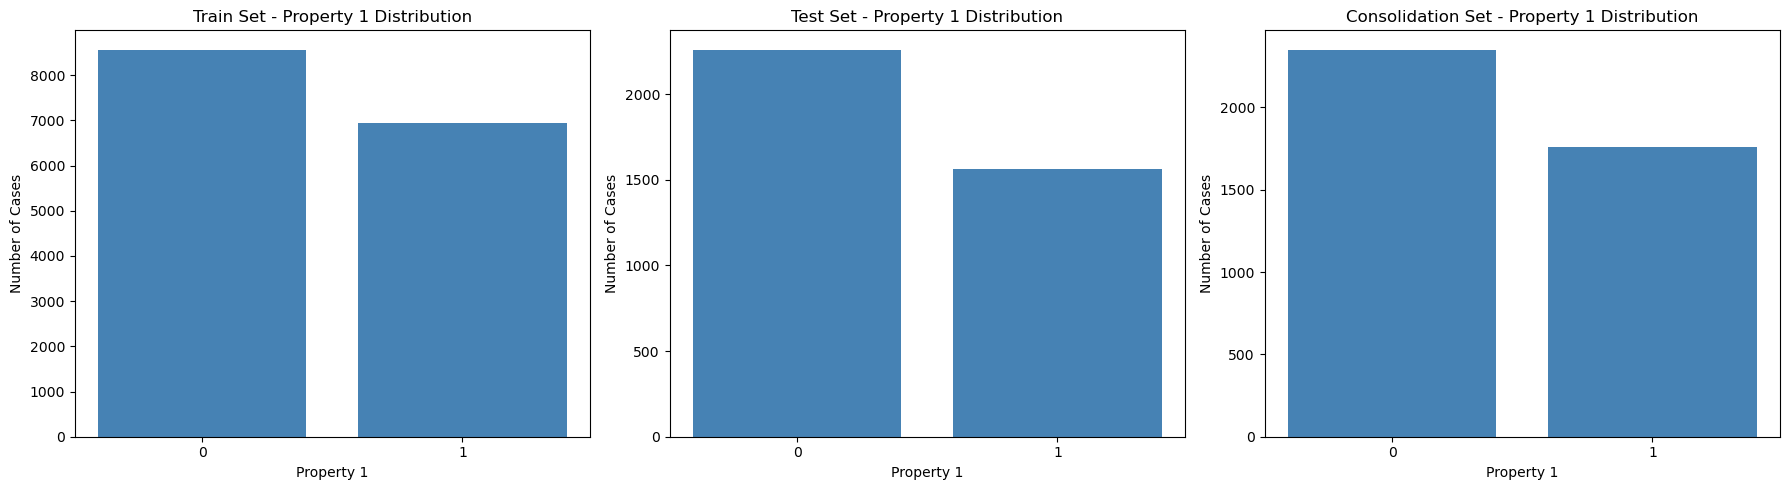

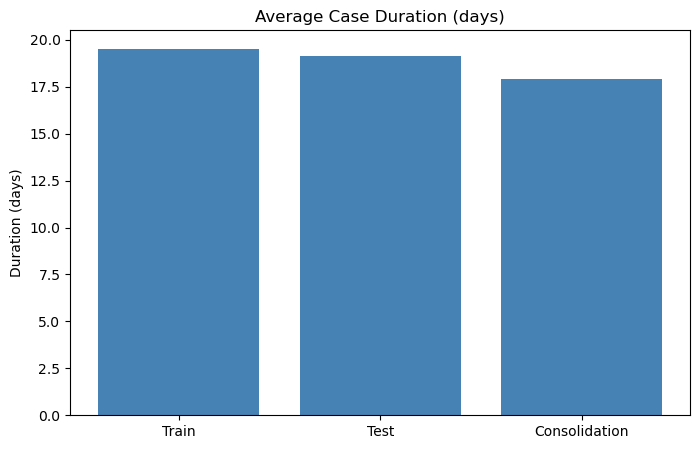

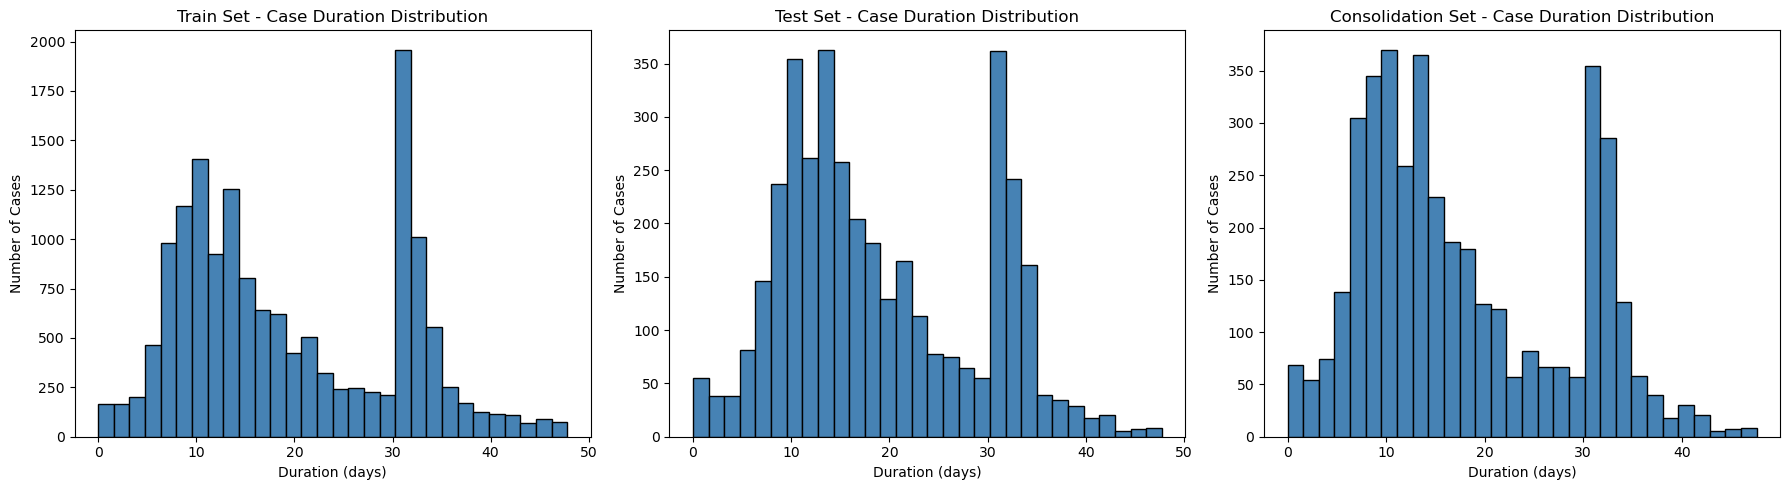

In [28]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Definisci la cartella di input (quella in cui esistono già i file CSV)
input_dir = "remove_partial"  # Modifica se necessario
# Nomi dei file già esistenti
train_file = os.path.join(input_dir, "train_set.csv")
test_file = os.path.join(input_dir, "test_set.csv")
cons_file = os.path.join(input_dir, "consolidation_set.csv")

# Funzione per aggiungere la colonna "Property 1"
def add_property(df):
    property_dict = {}
    for case in df["case:concept:name"].unique():
        case_df = df[df["case:concept:name"] == case]
        submitted = case_df[case_df["concept:name"] == "A_Submitted"]
        sent = case_df[case_df["concept:name"] == "O_Sent"]
        if submitted.empty or sent.empty:
            property_dict[case] = 0
        else:
            # Prendi il tempo minimo per A_Submitted e O_Sent
            sub_time = submitted["end_time"].min()
            sent_time = sent["end_time"].min()
            diff = (sent_time - sub_time).total_seconds() / 3600  # in ore
            property_dict[case] = 1 if diff <= 48 else 0
    df["Property 1"] = df["case:concept:name"].map(property_dict)
    return df

# Carica i file CSV
train_df = pd.read_csv(train_file)
test_df = pd.read_csv(test_file)
cons_df = pd.read_csv(cons_file)

# Assicurati che la colonna 'end_time' sia in formato datetime
train_df['end_time'] = pd.to_datetime(train_df['end_time'])
test_df['end_time'] = pd.to_datetime(test_df['end_time'])
cons_df['end_time'] = pd.to_datetime(cons_df['end_time'])

# Applica la funzione per aggiungere "Property 1" e sovrascrivi i file
train_df = add_property(train_df)
test_df = add_property(test_df)
cons_df = add_property(cons_df)

# Salva i file aggiornati (sovrascrivendo quelli esistenti)
train_df.to_csv(train_file, index=False)
test_df.to_csv(test_file, index=False)
cons_df.to_csv(cons_file, index=False)

# Calcola la distribuzione di "Property 1" per ciascun set (prendendo il primo valore per caso)
train_prop = train_df.groupby("case:concept:name")["Property 1"].first().value_counts().sort_index()
test_prop = test_df.groupby("case:concept:name")["Property 1"].first().value_counts().sort_index()
cons_prop = cons_df.groupby("case:concept:name")["Property 1"].first().value_counts().sort_index()

# Calcola la durata di ciascun caso (in giorni) per ogni set
def compute_case_duration(df):
    durations = df.groupby("case:concept:name")["end_time"].agg(lambda x: (x.max() - x.min()).total_seconds()/(24*3600))
    return durations

train_durations = compute_case_duration(train_df)
test_durations = compute_case_duration(test_df)
cons_durations = compute_case_duration(cons_df)

# Calcola la durata media per ciascun set
avg_train_duration = train_durations.mean()
avg_test_duration = test_durations.mean()
avg_cons_duration = cons_durations.mean()

print("Average case duration (days):")
print(f"Train set: {avg_train_duration:.2f}")
print(f"Test set: {avg_test_duration:.2f}")
print(f"Consolidation set: {avg_cons_duration:.2f}")

# Imposta un colore fisso per tutti i grafici
color_set = "steelblue"

# Crea grafici per la distribuzione di Property 1
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
axs[0].bar(train_prop.index.astype(str), train_prop.values, color=color_set)
axs[0].set_title("Train Set - Property 1 Distribution")
axs[0].set_xlabel("Property 1")
axs[0].set_ylabel("Number of Cases")

axs[1].bar(test_prop.index.astype(str), test_prop.values, color=color_set)
axs[1].set_title("Test Set - Property 1 Distribution")
axs[1].set_xlabel("Property 1")
axs[1].set_ylabel("Number of Cases")

axs[2].bar(cons_prop.index.astype(str), cons_prop.values, color=color_set)
axs[2].set_title("Consolidation Set - Property 1 Distribution")
axs[2].set_xlabel("Property 1")
axs[2].set_ylabel("Number of Cases")

plt.tight_layout()
plt.show()

# Grafico delle durate medie dei casi per ogni set
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(["Train", "Test", "Consolidation"], [avg_train_duration, avg_test_duration, avg_cons_duration], color=color_set)
ax.set_title("Average Case Duration (days)")
ax.set_ylabel("Duration (days)")
plt.show()

# Istogramma della distribuzione delle durate dei casi per ogni set
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
axs[0].hist(train_durations, bins=30, color=color_set, edgecolor="black")
axs[0].set_title("Train Set - Case Duration Distribution")
axs[0].set_xlabel("Duration (days)")
axs[0].set_ylabel("Number of Cases")

axs[1].hist(test_durations, bins=30, color=color_set, edgecolor="black")
axs[1].set_title("Test Set - Case Duration Distribution")
axs[1].set_xlabel("Duration (days)")
axs[1].set_ylabel("Number of Cases")

axs[2].hist(cons_durations, bins=30, color=color_set, edgecolor="black")
axs[2].set_title("Consolidation Set - Case Duration Distribution")
axs[2].set_xlabel("Duration (days)")
axs[2].set_ylabel("Number of Cases")

plt.tight_layout()
plt.show()